# Análise de Receita de Planos de Telecomunicações

**Autor:** Bruno Nogueira  
**Projeto:** Análise de comportamento de clientes e receita de planos pré-pagos da empresa Megaline.  
**Ferramentas:** Python, Pandas, NumPy, Matplotlib, SciPy  

## Contexto

A empresa de telecomunicações Megaline oferece dois planos pré-pagos para seus clientes: **Surf** e **Ultimate**.

O departamento comercial deseja entender qual dos planos gera **maior receita média** para a empresa, a fim de orientar decisões estratégicas e otimizar o orçamento de marketing.

Para isso, será realizada uma análise exploratória e estatística baseada em dados de **500 clientes**, incluindo informações de chamadas, mensagens de texto, uso de internet e características dos planos.

O objetivo deste estudo é analisar o comportamento dos clientes e identificar **qual plano gera maior receita média**, utilizando técnicas de análise de dados e testes estatísticos.

## Objetivos da Análise

Este projeto tem como objetivo:

- Preparar e tratar os dados fornecidos pela empresa Megaline
- Analisar o comportamento de uso dos clientes em relação a chamadas, mensagens e internet
- Calcular a receita mensal gerada por cada cliente
- Comparar o desempenho financeiro dos planos **Surf** e **Ultimate**
- Aplicar testes estatísticos para verificar se há diferença significativa entre as receitas médias dos planos

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Carregue os dados

Os dados utilizados nesta análise estão distribuídos em cinco tabelas:

- **users** — informações sobre os clientes
- **calls** — registros de chamadas realizadas
- **messages** — registros de mensagens enviadas
- **internet** — sessões de uso de dados móveis
- **plans** — características dos planos oferecidos pela empresa

In [3]:
# os arquivos de dados em diferentes DataFrames
megaline_calls = pd.read_csv("C:/Users/bruno/TripleTen/projeto_4/megaline_calls.csv")
megaline_internet = pd.read_csv("C:/Users/bruno/TripleTen/projeto_4/megaline_internet.csv")
megaline_messages = pd.read_csv("C:/Users/bruno/TripleTen/projeto_4/megaline_messages.csv")
megaline_plans =  pd.read_csv("C:/Users/bruno/TripleTen/projeto_4/megaline_plans.csv")
megaline_users = pd.read_csv("C:/Users/bruno/TripleTen/projeto_4/megaline_users.csv")

## Preparando os dados

## Planos

### Análise inicial da tabela de planos

Nesta etapa será realizada uma inspeção inicial do conjunto de dados **megaline_plans**, que contém as características dos planos oferecidos pela empresa.

O objetivo é entender:

- Estrutura das colunas
- Tipos de dados
- Possíveis valores ausentes
- Informações relevantes sobre os planos disponíveis

In [7]:
# Informações gerais/resumo sobre o DataFrame dos planos
megaline_plans.info()
megaline_users['user_id'].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


500

In [6]:
# Amostra de dados dos planos
megaline_plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


#### Observações

A tabela **megaline_plans** apresenta as características dos dois planos disponíveis para os clientes da Megaline:

Para cada plano são definidos:

- Valor mensal do plano
- Quantidade de minutos incluídos
- Quantidade de mensagens incluídas
- Volume de dados incluídos
- Custos adicionais por uso excedente

## Correção de dados

Após a análise inicial da tabela de planos, não foram identificados problemas evidentes de qualidade nos dados.

A tabela possui apenas dois registros, correspondentes aos planos **Surf** e **Ultimate**, e todas as colunas apresentam valores preenchidos e tipos de dados adequados.

Dessa forma, não são necessárias correções adicionais nesta etapa.

## Usuários

### Análise inicial da tabela de usuários

A tabela **megaline_users** contém informações sobre os clientes da empresa.

Entre os dados disponíveis estão:

- Identificador do usuário
- Nome e sobrenome
- Idade
- Data de registro no serviço
- Cidade de residência
- Plano contratado

Nesta etapa será realizada uma inspeção inicial da estrutura da tabela para identificar possíveis inconsistências ou necessidades de tratamento dos dados.

In [8]:
# Informações gerais/resumo sobre o DataFrame dos usuários
megaline_users.info()
megaline_users['age'].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


count    500.000000
mean      45.486000
std       16.972269
min       18.000000
25%       30.000000
50%       46.000000
75%       61.000000
max       75.000000
Name: age, dtype: float64

In [9]:
# Amostra de dados dos usuários
megaline_users.head(20)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


#### Observações

A tabela **megaline_users** apresenta informações sobre os clientes da empresa.

Durante a inspeção inicial foi possível identificar que as colunas **reg_date** e **churn_date** estão no formato object. Para facilitar análises futuras, essas colunas serão convertidas para o tipo **datetime**.

Também foi observado que existem valores **NaN** na coluna **churn_date**, o que é esperado, pois indica clientes que ainda não cancelaram o serviço.


### Correção dos dados identificados

In [10]:
#print (megaline_users['user_id'].duplicated().sum()) 
megaline_users['reg_date'] = pd.to_datetime(megaline_users['reg_date'])
megaline_users['churn_date'] = pd.to_datetime(megaline_users['churn_date'])
megaline_users.info()
#print()
#megaline_users['plan'].value_counts()
megaline_users.head(15)

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaT
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaT
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaT
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaT


### Enriquecimento dos dados

Para facilitar as análises posteriores, criei algumas variáveis adicionais a partir das informações da tabela **megaline_users**.

As novas colunas adicionadas foram:

- **status**: indica se o cliente está ativo ou se já cancelou o serviço.  
  - Clientes com valor nulo em churn_date foram classificados como **ativos**.
  - Clientes com data de cancelamento foram classificados como **cancelados**.

- **city_short**: versão simplificada da coluna city, contendo apenas o nome principal da cidade.  

- **lifetime_days**: representa o tempo de permanência do cliente no serviço (em dias).  
  Esse valor foi calculado utilizando:
  - a data de registro (reg_date)
  - a data de cancelamento (churn_date) ou, caso o cliente ainda esteja ativo, a data final da análise (**31/12/2018**).

In [12]:
megaline_users['status'] = megaline_users['churn_date'].apply(lambda x: 'ativo' if pd.isna(x) else 'cancelado')
megaline_users['city_short'] = megaline_users['city'].str.split('-').str[0].str.strip()

'''
consduzindo as análises com a data final em dez 2018
'''

end_date = pd.Timestamp('2018-12-31') #definindo o fim de análise

'''
definindo lifetime dos planos
'''
megaline_users['lifetime_days'] = ((megaline_users['churn_date'].fillna(end_date) - megaline_users['reg_date']).dt.days)
megaline_users.head(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,status,city_short,lifetime_days
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,ativo,Atlanta,7
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,ativo,Seattle,140
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,ativo,Las Vegas,71
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,ativo,"Tulsa, OK MSA",337
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,ativo,Seattle,222
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaT,ativo,Dallas,32
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18,cancelado,San Francisco,21
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaT,ativo,Grand Rapids,173
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaT,ativo,Orlando,150
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaT,ativo,San Jose,253


In [13]:
megaline_users['lifetime_days'].describe()

count    500.000000
mean     185.908000
std      103.986913
min        0.000000
25%       97.750000
50%      188.500000
75%      272.000000
max      364.000000
Name: lifetime_days, dtype: float64

## Chamadas

A tabela **megaline_calls** contém os registros de chamadas realizadas pelos usuários ao longo do período analisado.

Cada registro representa uma chamada individual e inclui:

- **id**: identificador único da chamada
- **user_id**: identificador do usuário que realizou a chamada
- **call_date**: data da chamada
- **duration**: duração da chamada em minutos

Nesta etapa será feita uma inspeção inicial da estrutura dos dados para identificar possíveis problemas de qualidade, como valores ausentes ou tipos de dados incorretos.

In [14]:
# Informações gerais/resumo sobre o DataFrame das chamadas
megaline_calls.info()
print(megaline_calls.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
id           0
user_id      0
call_date    0
duration     0
dtype: int64


In [15]:
# Amostra de dados das chamadas
megaline_calls.head(20)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


#### Observações

A tabela **megaline_calls** possui mais de 137 mil registros de chamadas realizadas pelos usuários.

Durante a inspeção inicial foi possível observar que:

- Não existem valores ausentes nas colunas analisadas.
- A coluna **call_date** está no formato object e precisará ser convertida para o tipo **datetime** para facilitar análises temporais.
- A coluna **duration** representa a duração das chamadas em minutos.

Na próxima etapa será realizada a conversão da coluna de data e a preparação dos dados para análises mensais.



### Corrigindo os dados

In [16]:
#print (megaline_calls['id'].duplicated().sum()) 
megaline_calls['call_date'] = pd.to_datetime(megaline_calls['call_date'])
megaline_calls['duration'] = np.ceil(megaline_calls['duration'])
megaline_calls.head(20)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
3,1000_309,1000,2018-12-28,6.0
4,1000_380,1000,2018-12-30,5.0
5,1000_388,1000,2018-12-31,3.0
6,1000_510,1000,2018-12-27,6.0
7,1000_521,1000,2018-12-28,15.0
8,1000_530,1000,2018-12-28,6.0
9,1000_544,1000,2018-12-26,5.0


### Enriqueceno os dados

As novas colunas adicionadas foram:

- **month**: representa o mês em que a chamada foi realizada.
- **year**: representa o ano da chamada.

Essas variáveis vão permitir agrupar os dados posteriormente por **usuário e período**, possibilitando calcular métricas mensais como:

- total de minutos utilizados por usuário
- quantidade de chamadas realizadas por mês

Essas informações serão utilizadas posteriormente no cálculo da **receita mensal por usuário**.

In [17]:
megaline_calls['month'] = megaline_calls['call_date'].dt.month
megaline_calls['year'] = megaline_calls['call_date'].dt.year
megaline_calls

,id,user_id,call_date,duration,month,year
0,1000_93,1000,2018-12-27,9.0,12,2018
1,1000_145,1000,2018-12-27,14.0,12,2018
2,1000_247,1000,2018-12-27,15.0,12,2018
3,1000_309,1000,2018-12-28,6.0,12,2018
4,1000_380,1000,2018-12-30,5.0,12,2018
...,...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,9.0,11,2018
137731,1499_200,1499,2018-10-20,11.0,10,2018
137732,1499_201,1499,2018-09-21,9.0,9,2018
137733,1499_202,1499,2018-10-10,1.0,10,2018


## Mensagens

A tabela **megaline_messages** contém os registros de mensagens de texto enviadas pelos usuários.

Cada registro representa uma mensagem individual e inclui:

- **id**: identificador único da mensagem
- **user_id**: identificador do usuário que enviou a mensagem
- **message_date**: data em que a mensagem foi enviada

Nesta etapa será realizada uma inspeção inicial da estrutura dos dados para verificar possíveis inconsistências, como valores ausentes ou tipos de dados inadequados.

In [18]:
# Informações gerais/resumo sobre o DataFrame das mensagens
megaline_messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [19]:
# Amostra dos dados das mensagens
megaline_messages.head(20)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


#### Observações

A tabela **megaline_messages** possui mais de 76 mil registros de mensagens enviadas pelos usuários.

Durante a inspeção inicial foi possível observar que:

- Não há valores ausentes nas colunas analisadas.
- A coluna **message_date** está no formato object e precisará ser convertida para o tipo **datetime** para permitir análises temporais.

Na próxima etapa será realizada a conversão da coluna de data e a preparação dos dados para análises mensais.

### Corrigindo os dados

In [22]:
#print (megaline_messages['id'].duplicated().sum()) verficando duplicatas
megaline_messages['message_date'] = pd.to_datetime(megaline_messages['message_date'])

### Enriqueçendo os dados

As novas colunas adicionadas foram:

- **month**: representa o mês em que a mensagem foi enviada.
- **year**: representa o ano da mensagem.

Essas variáveis permitirão agrupar os dados posteriormente por **usuário e período**, possibilitando calcular métricas mensais de envio de mensagens.

In [23]:
megaline_messages['year'] = megaline_messages['message_date'].dt.year
megaline_messages['month'] = megaline_messages['message_date'].dt.month
megaline_messages.head(15)

,id,user_id,message_date,year,month
0,1000_125,1000,2018-12-27,2018,12
1,1000_160,1000,2018-12-31,2018,12
2,1000_223,1000,2018-12-31,2018,12
3,1000_251,1000,2018-12-27,2018,12
4,1000_255,1000,2018-12-26,2018,12
5,1000_346,1000,2018-12-29,2018,12
6,1000_386,1000,2018-12-30,2018,12
7,1000_413,1000,2018-12-31,2018,12
8,1000_502,1000,2018-12-27,2018,12
9,1000_525,1000,2018-12-28,2018,12


## Internet

A tabela **megaline_internet** contém informações sobre o consumo de dados móveis pelos usuários da Megaline.

Cada registro representa uma sessão de uso de internet e inclui:

- **id**: identificador único da sessão
- **user_id**: identificador do usuário
- **session_date**: data da sessão de internet
- **mb_used**: volume de dados utilizado na sessão, em megabytes

Nesta etapa será realizada uma inspeção inicial dos dados para verificar possíveis inconsistências, valores ausentes ou tipos de dados inadequados.

In [24]:
# informações gerais/resumo sobre o DataFrame da internet
megaline_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [33]:
# amostra de dados para o tráfego da internet
megaline_internet.head(15)


,id,user_id,session_date,mb_used,year,month
0,1000_13,1000,2018-12-29,89.86,2018,12
1,1000_204,1000,2018-12-31,0.00,2018,12
2,1000_379,1000,2018-12-28,660.40,2018,12
3,1000_413,1000,2018-12-26,270.99,2018,12
4,1000_442,1000,2018-12-27,880.22,2018,12
5,1001_0,1001,2018-08-24,284.68,2018,8
6,1001_3,1001,2018-12-09,656.04,2018,12
7,1001_4,1001,2018-11-04,16.97,2018,11
8,1001_10,1001,2018-11-27,135.18,2018,11
9,1001_15,1001,2018-12-13,761.92,2018,12


#### Observações

Cada linha da tabela **megaline_internet** representa uma sessão individual de uso de dados móveis.

Alguns pontos observados:

- Não existem valores ausentes nas colunas analisadas.
- A coluna **session_date** está no formato object e precisa ser convertida para o tipo **datetime** para permitir análises temporais.
- A coluna **mb_used** representa o volume de dados consumido em megabytes em cada sessão.

De acordo com a descrição do projeto, o consumo de dados **não é arredondado por sessão**, sendo o arredondamento realizado apenas após a soma mensal do uso de dados.

### Corrigindo os dados

In [34]:
#print (megaline_internet['id'].duplicated().sum()) 
megaline_internet['session_date'] = pd.to_datetime(megaline_internet['session_date'])


### Enriqueçendo os dados

Para facilitar análises temporais e permitir agregações mensais do consumo de dados, foram criadas novas variáveis a partir da coluna **session_date**.

As novas colunas adicionadas foram:

- **month**: representa o mês da sessão de internet.
- **year**: representa o ano da sessão.

Essas variáveis permitirão calcular posteriormente o **volume total de dados consumido por usuário em cada mês**.

In [35]:
megaline_internet['year'] = megaline_internet['session_date'].dt.year
megaline_internet['month'] = megaline_internet['session_date'].dt.month
megaline_internet

,id,user_id,session_date,mb_used,year,month
0,1000_13,1000,2018-12-29,89.86,2018,12
1,1000_204,1000,2018-12-31,0.00,2018,12
2,1000_379,1000,2018-12-28,660.40,2018,12
3,1000_413,1000,2018-12-26,270.99,2018,12
4,1000_442,1000,2018-12-27,880.22,2018,12
...,...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,2018,10
104821,1499_216,1499,2018-12-30,304.72,2018,12
104822,1499_217,1499,2018-09-22,292.75,2018,9
104823,1499_218,1499,2018-12-07,0.00,2018,12


## Estrutura dos planos tarifários

In [36]:
# Recordabdo condições dos planos
megaline_plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Construção das métricas mensais de uso

Após a preparação e limpeza dos dados, o próximo passo é consolidar o uso dos serviços por usuário e por período.

Como as tabelas de chamadas, mensagens e uso de internet registram eventos individuais (cada chamada, mensagem ou sessão de dados), é necessário agregar essas informações para obter métricas mensais por usuário.

Essas métricas permitirão calcular posteriormente:

- total de chamadas realizadas
- total de minutos utilizados
- total de mensagens enviadas
- volume de dados consumidos

Essas informações serão fundamentais para calcular a **receita mensal gerada por cada usuário**.

In [37]:
# Cálculo do número de chamadas feitas por cada usuário por mês.
calls_per_month = (megaline_calls.groupby(['user_id', 'year', 'month'], as_index=False).agg({'id': 'count'}).rename(columns={'id': 'total_calls'}))

calls_per_month.head(25)


,user_id,year,month,total_calls
0,1000,2018,12,16
1,1001,2018,8,27
2,1001,2018,9,49
3,1001,2018,10,65
4,1001,2018,11,64
5,1001,2018,12,56
6,1002,2018,10,11
7,1002,2018,11,55
8,1002,2018,12,47
9,1003,2018,12,149


In [38]:
# Calculo da quantidade de minutos gastos por cada usuário por mês. 
minutes_per_month = (megaline_calls.groupby(['user_id','year', 'month'], as_index=False).agg({'duration': 'sum'}).rename(columns={'duration': 'total_minutes'}))

minutes_per_month.head()


,user_id,year,month,total_minutes
0,1000,2018,12,124.0
1,1001,2018,8,182.0
2,1001,2018,9,315.0
3,1001,2018,10,393.0
4,1001,2018,11,426.0


In [39]:
# Calculo do número de mensagens enviadas por cada usuário por mês. 
messages_per_month = (megaline_messages.groupby(['user_id', 'year', 'month'], as_index=False).agg({'id': 'count'}).rename(columns={'id': 'total_messages'}))

messages_per_month.head(20)

,user_id,year,month,total_messages
0,1000,2018,12,11
1,1001,2018,8,30
2,1001,2018,9,44
3,1001,2018,10,53
4,1001,2018,11,36
5,1001,2018,12,44
6,1002,2018,10,15
7,1002,2018,11,32
8,1002,2018,12,41
9,1003,2018,12,50


In [40]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

internet_per_month = (megaline_internet.groupby(['user_id', 'year', 'month'], as_index=False).agg({'mb_used': 'sum'}).rename(columns={'mb_used': 'total_mb'}))
internet_per_month['total_gb'] = np.ceil(internet_per_month['total_mb'] / 1024)

internet_per_month.head(20)
                  

,user_id,year,month,total_mb,total_gb
0,1000,2018,12,1901.47,2.0
1,1001,2018,8,6919.15,7.0
2,1001,2018,9,13314.82,14.0
3,1001,2018,10,22330.49,22.0
4,1001,2018,11,18504.30,19.0
5,1001,2018,12,19369.18,19.0
6,1002,2018,10,6552.01,7.0
7,1002,2018,11,19345.08,19.0
8,1002,2018,12,14396.24,15.0
9,1003,2018,12,27044.14,27.0


In [41]:
# Agrupamento dos dados de chamadas, minutos, mensagens e internet com base em user_id e month
user_monthly = (
    calls_per_month.merge(minutes_per_month, on=['user_id','month'], how='outer').merge(messages_per_month, on=['user_id','month'], how='outer').merge(internet_per_month[['user_id','month','total_gb']], on=['user_id','month'], how='outer').fillna({'total_calls':0,'total_minutes':0,'total_messages':0,'total_gb':0})
)

user_monthly = user_monthly.rename(columns={'year_x': 'years'}).drop(columns=['year_y'], errors='ignore')
user_monthly = user_monthly[['user_id', 'year', 'month', 'total_calls', 'total_minutes', 'total_messages', 'total_gb']]

user_monthly.head(25)



,user_id,year,month,total_calls,total_minutes,total_messages,total_gb
0,1000,2018.0,12,16.0,124.0,11.0,2.0
1,1001,2018.0,8,27.0,182.0,30.0,7.0
2,1001,2018.0,9,49.0,315.0,44.0,14.0
3,1001,2018.0,10,65.0,393.0,53.0,22.0
4,1001,2018.0,11,64.0,426.0,36.0,19.0
5,1001,2018.0,12,56.0,412.0,44.0,19.0
6,1002,2018.0,10,11.0,59.0,15.0,7.0
7,1002,2018.0,11,55.0,386.0,32.0,19.0
8,1002,2018.0,12,47.0,384.0,41.0,15.0
9,1003,2018.0,12,149.0,1104.0,50.0,27.0


Após a agregação das métricas de uso e a união das tabelas de chamadas, minutos, mensagens e uso de internet, foi criado o dataset **user_monthly**, que contém um registro por usuário para cada mês.

Esse dataset reúne as principais métricas de utilização dos serviços da Megaline:

- **total_calls** → número total de chamadas realizadas no mês
- **total_minutes** → total de minutos utilizados em chamadas
- **total_messages** → número total de mensagens enviadas
- **total_gb** → volume total de dados móveis consumidos

Com essas informações consolidadas, torna-se possível analisar o comportamento de uso dos clientes de forma mensal e calcular posteriormente a **receita gerada por cada usuário**, considerando os limites e excedentes definidos nos planos.

Esse dataset será utilizado nas próximas etapas para integrar as informações de usuários e planos tarifários, permitindo calcular a receita mensal e realizar análises comparativas entre os planos **Surf** e **Ultimate**.

### Integração das informações de usuários e planos

Após consolidar as métricas mensais de uso, vi necessário integrar as informações dos usuários e dos planos tarifários ao dataset analítico.

Essa etapa permite associar cada usuário ao plano contratado, além de incluir as condições tarifárias de cada plano, como:

- valor mensal da assinatura
- minutos incluídos
- mensagens incluídas
- volume de dados incluído
- custos por excedente

Essas informações são necessárias para calcular a **receita mensal gerada por cada usuário**.

In [42]:
# Integração das informações de usuários e planos tarifários
user_plans = megaline_users[['user_id', 'plan']]
user_monthly = user_monthly.merge(user_plans, on='user_id', how='left')

user_monthly = user_monthly.merge(
    megaline_plans,
    left_on='plan',      
    right_on='plan_name', 
    how='left'
)
user_monthly = user_monthly.drop(columns=['plan_name'], errors='ignore')

user_monthly.head(20)


,user_id,year,month,total_calls,total_minutes,total_messages,total_gb,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,2018.0,12,16.0,124.0,11.0,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01
1,1001,2018.0,8,27.0,182.0,30.0,7.0,surf,50,15360,500,20,10,0.03,0.03
2,1001,2018.0,9,49.0,315.0,44.0,14.0,surf,50,15360,500,20,10,0.03,0.03
3,1001,2018.0,10,65.0,393.0,53.0,22.0,surf,50,15360,500,20,10,0.03,0.03
4,1001,2018.0,11,64.0,426.0,36.0,19.0,surf,50,15360,500,20,10,0.03,0.03
5,1001,2018.0,12,56.0,412.0,44.0,19.0,surf,50,15360,500,20,10,0.03,0.03
6,1002,2018.0,10,11.0,59.0,15.0,7.0,surf,50,15360,500,20,10,0.03,0.03
7,1002,2018.0,11,55.0,386.0,32.0,19.0,surf,50,15360,500,20,10,0.03,0.03
8,1002,2018.0,12,47.0,384.0,41.0,15.0,surf,50,15360,500,20,10,0.03,0.03
9,1003,2018.0,12,149.0,1104.0,50.0,27.0,surf,50,15360,500,20,10,0.03,0.03


### Cálculo da receita mensal

A receita mensal de cada usuário é calculada considerando:

1. O valor fixo do plano contratado.
2. Possíveis cobranças adicionais por excedente de uso.

Os excedentes são calculados da seguinte forma:

- minutos excedentes = minutos utilizados - minutos incluídos no plano
- mensagens excedentes = mensagens enviadas - mensagens incluídas
- dados excedentes = volume de dados consumido acima do limite do plano

Caso o usuário não ultrapasse o limite incluído no plano, o valor excedente é considerado zero.

O valor final da receita mensal corresponde à soma:

- valor da assinatura mensal
- cobranças adicionais por minutos excedentes
- cobranças adicionais por mensagens excedentes
- cobranças adicionais por dados excedentes

In [43]:
# Cálculo da receita mensal por usuário com base nas regras dos planos

user_monthly['over_minutes'] = (user_monthly['total_minutes'] - user_monthly['minutes_included']).clip(lower=0)
user_monthly['over_messages'] = (user_monthly['total_messages'] - user_monthly['messages_included']).clip(lower=0)

user_monthly['included_gb'] = np.ceil(user_monthly['mb_per_month_included'] / 1024)
user_monthly['over_gb'] = (user_monthly['total_gb'] - user_monthly['included_gb']).clip(lower=0)

user_monthly['charge_minutes'] = user_monthly['over_minutes'] * user_monthly['usd_per_minute']
user_monthly['charge_messages'] = user_monthly['over_messages'] * user_monthly['usd_per_message']
user_monthly['charge_gb'] = user_monthly['over_gb'] * user_monthly['usd_per_gb']

user_monthly['monthly_revenue'] = (user_monthly['usd_monthly_pay'] +user_monthly['charge_minutes'] + user_monthly['charge_messages'] + user_monthly['charge_gb']).round(2)

user_monthly[['user_id','year','month','plan','monthly_revenue']].head(30)



,user_id,year,month,plan,monthly_revenue
0,1000,2018.0,12,ultimate,70.00
1,1001,2018.0,8,surf,20.00
2,1001,2018.0,9,surf,20.00
3,1001,2018.0,10,surf,90.09
4,1001,2018.0,11,surf,60.00
5,1001,2018.0,12,surf,60.00
6,1002,2018.0,10,surf,20.00
7,1002,2018.0,11,surf,60.00
8,1002,2018.0,12,surf,20.00
9,1003,2018.0,12,surf,158.12


#### Observações

A nova coluna **monthly_revenue** representa a receita mensal gerada por cada usuário.

Essa variável será utilizada nas próximas etapas para:

- comparar o desempenho financeiro dos planos **Surf** e **Ultimate**
- analisar padrões de uso dos clientes
- realizar testes estatísticos para verificar diferenças significativas entre os planos

## Análise exploratória do comportamento dos usuários

### Uso de chamadas por plano

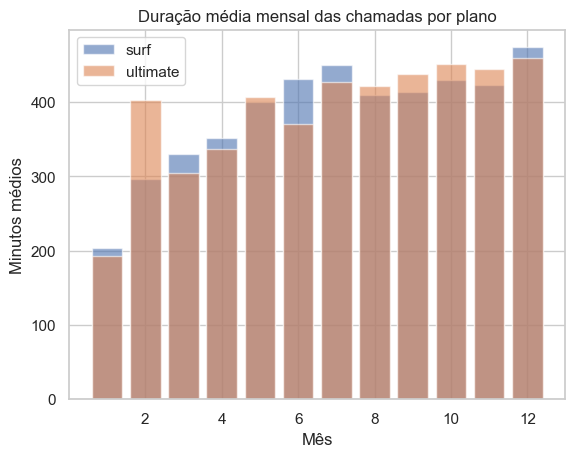

In [45]:
# Comparação da duração média das chamadas de cada plano para cada mês.

avg_minutes = (
    user_monthly
    .groupby(['plan', 'month'])['total_minutes']
    .mean()
    .reset_index()
)

avg_minutes

for plan in avg_minutes['plan'].unique():
    data = avg_minutes[avg_minutes['plan'] == plan]
    plt.bar(
        data['month'],
        data['total_minutes'],
        alpha=0.6,
        label=plan
    )

plt.title('Duração média mensal das chamadas por plano')
plt.xlabel('Mês')
plt.ylabel('Minutos médios')
plt.legend()
plt.show()



#### Observações

O gráfico mostra a média mensal de minutos utilizados pelos usuários de cada plano.

Alguns pontos podem ser observados:

- Usuários do plano **Ultimate** tendem a apresentar um consumo médio de minutos maior em comparação ao plano **Surf**.
- Isso é esperado, pois o plano Ultimate oferece um limite significativamente maior de minutos incluídos na assinatura mensal.
- Usuários com planos mais robustos tendem a utilizar mais os recursos disponíveis, possivelmente devido à menor preocupação com custos adicionais.

Também é possível notar variações ao longo dos meses, indicando que o comportamento de uso não é completamente estável ao longo do tempo.

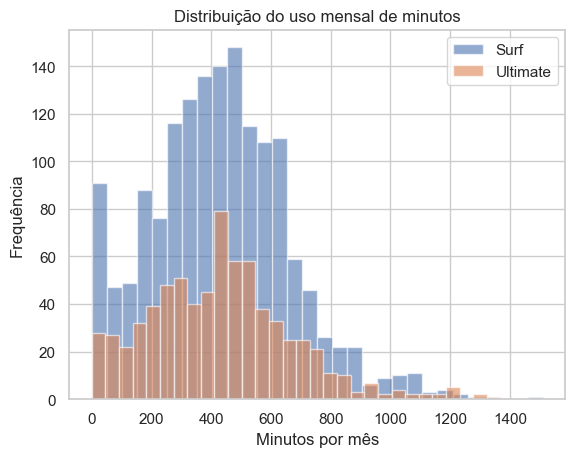

In [47]:
# Comparando o número de minutos que os usuários de cada plano necessitam a cada mês.
user_monthly[user_monthly['plan'] == 'surf']['total_minutes'].hist(
    bins=30, alpha=0.6, label='Surf'
)

user_monthly[user_monthly['plan'] == 'ultimate']['total_minutes'].hist(
    bins=30, alpha=0.6, label='Ultimate'
)

plt.title('Distribuição do uso mensal de minutos')
plt.xlabel('Minutos por mês')
plt.ylabel('Frequência')
plt.legend()
plt.show()


Para analisar o comportamento de uso dos clientes, eu escolhi utilizar um **histograma**, pois esse tipo de gráfico permite visualizar a distribuição dos dados e identificar padrões de consumo entre os usuários.

#### Observações

A distribuição mostra diferenças interessantes entre os dois planos:

- Usuários do plano **Surf** apresentam maior concentração de consumo entre aproximadamente **300 e 700 minutos por mês**.
- Usuários do plano **Ultimate** também se concentram nessa faixa, porém apresentam maior dispersão, com alguns usuários consumindo volumes significativamente maiores de minutos.

Também é possível observar que:

- A distribuição não é perfeitamente simétrica, indicando que alguns usuários apresentam padrões de uso mais intensivos.
- O plano **Ultimate** apresenta maior variabilidade de consumo, o que é esperado devido ao limite muito maior de minutos incluídos no plano.

Esses padrões sugerem que usuários que optam pelo plano Ultimate podem possuir uma necessidade maior de utilização de chamadas ou se sentem mais confortáveis em utilizar o serviço devido ao limite mais alto de minutos incluídos.

In [32]:
# Calculo da média e a variância da duração mensal das chamadas

call_stats = (
    user_monthly
    .groupby('plan')['total_minutes']
    .agg(['mean', 'var'])
)

call_stats

,mean,var
plan,,
surf,428.749523,54968.279461
ultimate,430.450000,57844.464812


visualização → confirmação estatística 

**Constatação:** diferença muito pequena

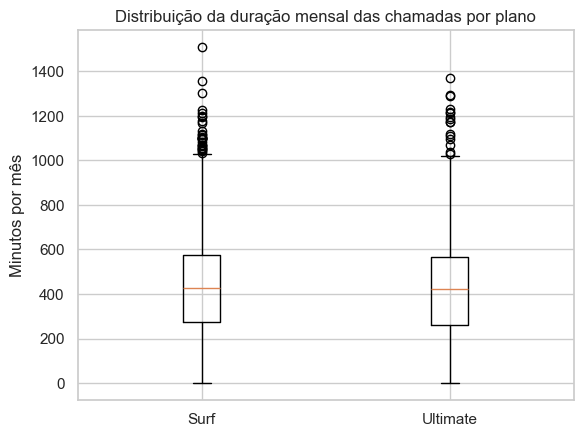

In [49]:
# Fazendo um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
data = [
    user_monthly[user_monthly['plan'] == 'surf']['total_minutes'],
    user_monthly[user_monthly['plan'] == 'ultimate']['total_minutes']
]

plt.boxplot(data, tick_labels=['Surf', 'Ultimate'])
plt.title('Distribuição da duração mensal das chamadas por plano')
plt.ylabel('Minutos por mês')
plt.show()


#### Análise do comportamento de chamadas

A análise das estatísticas descritivas e das visualizações indica que o comportamento de uso de chamadas é bastante parecido entre os usuários dos planos **Surf** e **Ultimate**.

As medianas observadas para os dois planos são muito próximas, sugerindo que o padrão típico de uso mensal de minutos é semelhante entre os grupos de usuários. Além disso, a amplitude interquartil apresenta valores comparáveis, indicando níveis de dispersão similares no consumo de minutos.

A análise das médias mensais aponta que os usuários do plano **Ultimate** tendem a utilizar, em média, um volume ligeiramente maior de minutos por mês em comparação aos usuários do plano **Surf**. Porém, os histogramas e os diagramas de caixa mostram que a distribuição do uso mensal de minutos é bastante parecida entre os dois planos.

Também foi possível observar a presença de **valores extremos (outliers)** em ambos os planos, indicando que existem usuários com consumo significativamente mais alto de minutos. Isso sugere que o plano contratado, por si só, não é o único fator determinante para o volume de chamadas realizadas.

Em resumo, os resultados indicam que o comportamento de uso de chamadas não difere de maneira significativa entre os planos Surf e Ultimate. As diferenças observadas são relativamente pequenas e parecem estar mais relacionadas à variabilidade natural do comportamento dos usuários do que a diferenças estruturais entre os planos.

### Uso de mensagens por plano

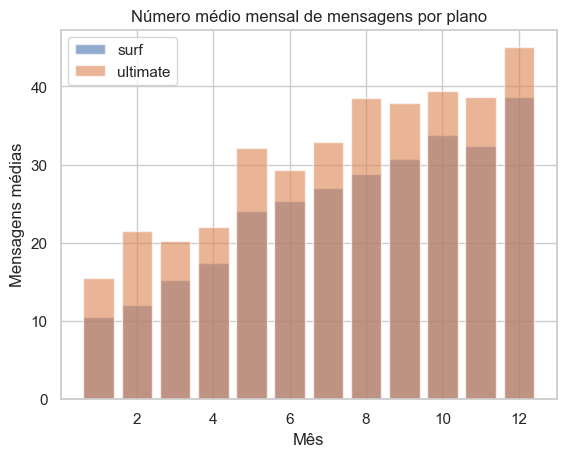

In [50]:
# Comparando o número de mensagens que os usuários de cada plano costumam enviar a cada mês
avg_messages = (
    user_monthly
    .groupby(['plan', 'month'])['total_messages']
    .mean()
    .reset_index()
)

avg_messages

for plan in avg_messages['plan'].unique():
    data = avg_messages[avg_messages['plan'] == plan]
    plt.bar(
        data['month'],
        data['total_messages'],
        alpha=0.6,
        label=plan
    )

plt.title('Número médio mensal de mensagens por plano')
plt.xlabel('Mês')
plt.ylabel('Mensagens médias')
plt.legend()
plt.show()

#### Análise do comportamento de mensagens

O número médio mensal de mensagens enviadas indica que os usuários do plano **Ultimate** tendem a enviar, em média, um volume ligeiramente maior de mensagens ao longo dos meses quando comparados aos usuários do plano **Surf**.

Há também uma tendência de crescimento gradual no número médio de mensagens enviadas ao longo do ano para ambos os planos, o que pode refletir mudanças no comportamento de uso dos clientes ou maior adoção do serviço ao longo do tempo.

Apesar dessa diferença, os padrões de crescimento são relativamente semelhantes entre os dois planos, sugerindo que o tipo de plano contratado não altera drasticamente o comportamento geral de envio de mensagens, embora usuários do plano Ultimate apresentem um nível de uso consistentemente um pouco maior.

### Uso de internet por plano

In [51]:
# Comparando a quantidade de tráfego de internet consumido pelos usuários por plano
avg_internet = (
    user_monthly
    .groupby(['plan', 'month'])['total_gb']
    .mean()
    .reset_index()
)

avg_internet


,plan,month,total_gb
0,surf,1,5.000000
1,surf,2,12.222222
2,surf,3,13.565217
3,surf,4,12.220000
4,surf,5,14.116883
5,surf,6,15.484536
6,surf,7,16.876033
7,surf,8,16.882716
8,surf,9,16.690722
9,surf,10,17.409283


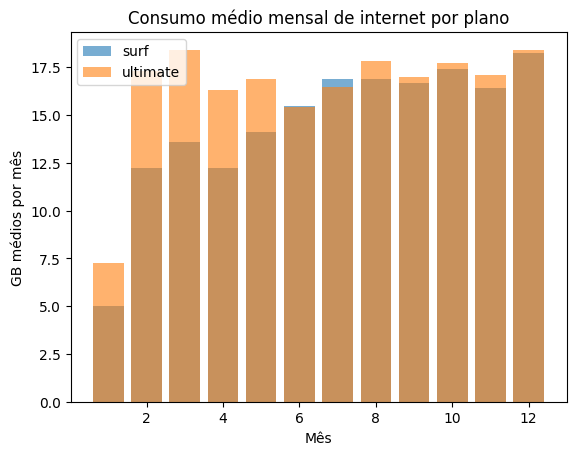

In [36]:
for plan in avg_internet['plan'].unique():
    data = avg_internet[avg_internet['plan'] == plan]
    plt.bar(
        data['month'],
        data['total_gb'],
        alpha=0.6,
        label=plan
    )

plt.title('Consumo médio mensal de internet por plano')
plt.xlabel('Mês')
plt.ylabel('GB médios por mês')
plt.legend()
plt.show()

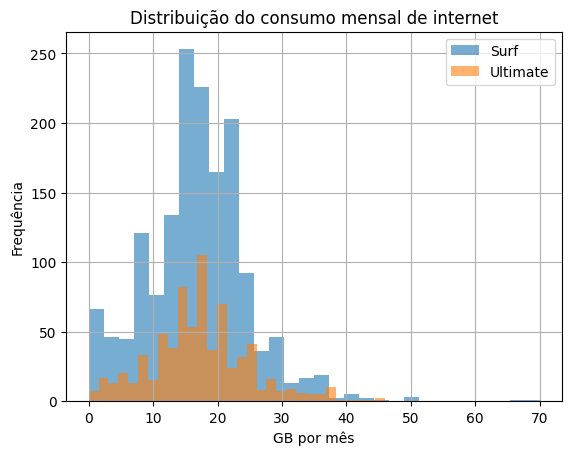

In [37]:
user_monthly[user_monthly['plan'] == 'surf']['total_gb'].hist(
    bins=30, alpha=0.6, label='Surf'
)

user_monthly[user_monthly['plan'] == 'ultimate']['total_gb'].hist(
    bins=30, alpha=0.6, label='Ultimate'
)

plt.title('Distribuição do consumo mensal de internet')
plt.xlabel('GB por mês')
plt.ylabel('Frequência')
plt.legend()
plt.show()

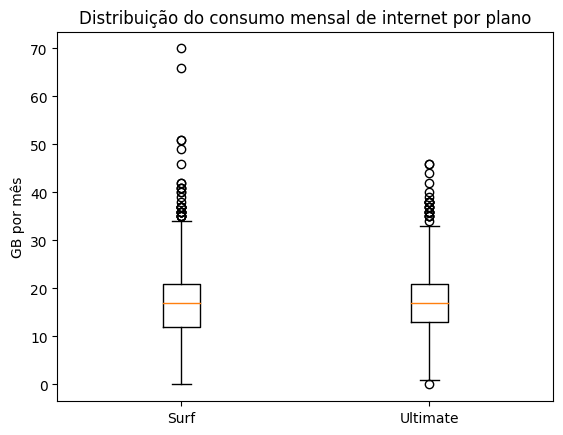

In [38]:
data = [
    user_monthly[user_monthly['plan'] == 'surf']['total_gb'],
    user_monthly[user_monthly['plan'] == 'ultimate']['total_gb']
]

plt.boxplot(data, labels=['Surf', 'Ultimate'])
plt.title('Distribuição do consumo mensal de internet por plano')
plt.ylabel('GB por mês')
plt.show()

#### Análise do comportamento do trafego de internet


Observando os gráficos de consumo de internet, é possível notar que os usuários do plano **Ultimate** tendem a utilizar um pouco mais de dados ao longo dos meses quando comparados aos usuários do plano **Surf**. Isso já era esperado, já que o plano Ultimate oferece uma franquia maior de dados incluídos.

Pelo histograma, dá para perceber que a maior parte dos usuários de ambos os planos concentra seu consumo em uma faixa relativamente parecida, principalmente entre cerca de **10 GB e 30 GB por mês**. Ou seja, apesar das diferenças entre os planos, o comportamento geral de uso de internet parece bastante semelhante para a maioria dos clientes.

O boxplot também mostra a presença de alguns **valores extremos**, indicando que existem usuários com um consumo de dados bem acima da média. Esses casos provavelmente representam clientes que utilizam internet de forma mais intensiva, independentemente do plano contratado.

De forma geral, o plano Ultimate apresenta um consumo médio um pouco maior, mas os padrões de uso de internet entre os dois planos não são drasticamente diferenteb. A principal diferença parece estar na presença de alguns usuários com consumo mais elevado.



## Receita

In [39]:
revenue_stats = (
    user_monthly
    .groupby('plan')['monthly_revenue']
    .agg(['mean', 'var', 'std'])
)

revenue_stats

,mean,var,std
plan,,,
surf,60.706408,3067.835152,55.388042
ultimate,72.313889,129.848486,11.395108


In [40]:
avg_revenue = (
    user_monthly
    .groupby(['plan', 'month'])['monthly_revenue']
    .mean()
    .reset_index()
)

avg_revenue

,plan,month,monthly_revenue
0,surf,1,20.000000
1,surf,2,34.396667
2,surf,3,45.941304
3,surf,4,40.710600
4,surf,5,47.628182
5,surf,6,49.276289
6,surf,7,62.674050
7,surf,8,63.931173
8,surf,9,58.271495
9,surf,10,65.421224


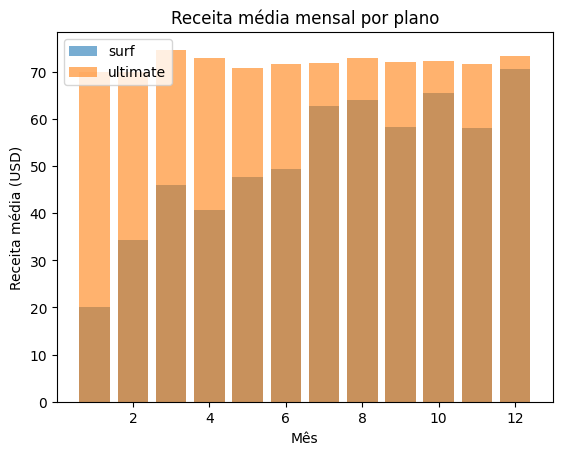

In [41]:
for plan in avg_revenue['plan'].unique():
    data = avg_revenue[avg_revenue['plan'] == plan]
    plt.bar(
        data['month'],
        data['monthly_revenue'],
        alpha=0.6,
        label=plan
    )

plt.title('Receita média mensal por plano')
plt.xlabel('Mês')
plt.ylabel('Receita média (USD)')
plt.legend()
plt.show()

#### Análise das receitas dos planos 

A análise da receita média mensal mostra uma diferença clara entre os planos **Surf** e **Ultimate**.

Como esperado, o plano **Ultimate** apresenta uma receita média mensal mais alta. Isso ocorre principalmente porque o valor base da assinatura desse plano é maior quando comparado ao plano Surf.

Observando o gráfico de receita média ao longo dos meses, também é possível perceber que a receita do plano Ultimate se mantém relativamente estável durante o período analisado. Isso indica que a maior parte da receita desse plano vem do valor fixo da assinatura, já que os limites incluídos são mais altos e reduzem a necessidade de cobranças adicionais por excedente.

Por outro lado, no plano **Surf** a receita média apresenta mais variações ao longo dos meses. Isso pode estar relacionado ao fato de que os limites incluídos nesse plano são menores, fazendo com que alguns usuários ultrapassem esses limites e gerem cobranças extras de minutos, mensagens ou dados.

De modo geral, em média, o plano Ultimate é mais rentável para a empresa Megaline.

## Teste de hipóteses estatísticas

Nesta etapa serão realizados testes estatísticos para verificar se as diferenças observadas nas análises exploratórias são estatisticamente significativas.

O objetivo é testar se existe evidência suficiente nos dados para afirmar que a receita média mensal dos usuários dos planos **Surf** e **Ultimate** é diferente.

Para isso, utilizamos um **teste t para duas amostras independentes**, comparando a média da receita mensal entre os dois grupos de usuários.

### Hipótese 1: Diferença na receita média entre os planos Surf e Ultimate

**Hipótese nula (H°):**  
A receita média mensal dos usuários do plano Surf é igual à receita média mensal dos usuários do plano Ultimate.

**Hipótese alternativa (H¹):**  
A receita média mensal dos usuários do plano Surf é diferente da receita média mensal dos usuários do plano Ultimate.

Para testar essa hipótese, foi adotado um nível de significância de 5% (α = 0,05).

In [42]:
# Teste das hipóteses
from scipy import stats

revenue_surf = user_monthly[user_monthly['plan'] == 'surf']['monthly_revenue']
revenue_ultimate = user_monthly[user_monthly['plan'] == 'ultimate']['monthly_revenue']

var_surf = revenue_surf.var()
var_ultimate = revenue_ultimate.var()

var_surf, var_ultimate



(3067.835152293878, 129.8484855509195)

In [43]:
t_stat, p_value = stats.ttest_ind(
    revenue_surf,
    revenue_ultimate,
    equal_var=False
)

t_stat, p_value

(-7.952094891333888, 3.1703905481135734e-15)

##### Resultado observado:

O valor-p obtido no teste t é menor que o nível de significância adotado (α = 0,05). Portanto, rejeita-se a hipótese nula.

### Hipótese 2: Diferença na receita média entre usuários da região NY–NJ e das demais regiões

**Hipótese nula (H°):**  
A receita média mensal dos usuários da região NY–NJ é igual à receita média mensal dos usuários das demais regiões.

**Hipótese alternativa (H¹):**  
A receita média mensal dos usuários da região NY–NJ é diferente da receita média mensal dos usuários das demais regiões.

Para testar essa hipótese, foi adotado um nível de significância de 5% (α = 0,05).

In [44]:
# Adicionando informação de região ao user_monthly
user_monthly = user_monthly.merge(
    megaline_users[['user_id', 'city_short']],
    on='user_id',
    how='left'
)

user_monthly.head()

,user_id,year,month,total_calls,total_minutes,total_messages,total_gb,plan,messages_included,mb_per_month_included,...,usd_per_minute,over_minutes,over_messages,included_gb,over_gb,charge_minutes,charge_messages,charge_gb,monthly_revenue,city_short
0,1000,2018.0,12,16.0,124.0,11.0,2.0,ultimate,1000,30720,...,0.01,0.0,0.0,30.0,0.0,0.0,0.00,0.0,70.00,Atlanta
1,1001,2018.0,8,27.0,182.0,30.0,7.0,surf,50,15360,...,0.03,0.0,0.0,15.0,0.0,0.0,0.00,0.0,20.00,Seattle
2,1001,2018.0,9,49.0,315.0,44.0,14.0,surf,50,15360,...,0.03,0.0,0.0,15.0,0.0,0.0,0.00,0.0,20.00,Seattle
3,1001,2018.0,10,65.0,393.0,53.0,22.0,surf,50,15360,...,0.03,0.0,3.0,15.0,7.0,0.0,0.09,70.0,90.09,Seattle
4,1001,2018.0,11,64.0,426.0,36.0,19.0,surf,50,15360,...,0.03,0.0,0.0,15.0,4.0,0.0,0.00,40.0,60.00,Seattle


In [45]:
# Teste das hipóteses

from scipy import stats

revenue_ny_nj = user_monthly[
    user_monthly['city_short'].isin(['New York', 'New Jersey'])]['monthly_revenue']

revenue_other = user_monthly[
    user_monthly['city_short'].isin(['New York', 'New Jersey']) == False]['monthly_revenue']

# Variâncias
var_ny_nj = revenue_ny_nj.var()
var_other = revenue_other.var()

var_ny_nj, var_other

(1895.5456899204246, 2225.0479943518917)

In [46]:
t_stat_region, p_value_region = stats.ttest_ind(
    revenue_ny_nj,
    revenue_other,
    equal_var=False
)

t_stat_region, p_value_region

(-2.1309454999502133, 0.0335256158853001)

Comparando as variâncias das duas amostras. A variância da receita mensal dos usuários de NY-NJ foi aproximadamente 1895.55 diferente das demais regiões.

Como as variâncias não são iguais, utilizamos o teste t. Adotamos um nível de significância α = 0.05. 

##### Resultado observado: 
O teste t resultou em um p-value menor que α, portanto rejeitamos a hipótese nula.


## Conclusão geral


##### Neste projeto, foi realizada uma análise do comportamento dos usuários e da receita gerada pelos planos pré-pagos Surf e Ultimate da empresa de telecomunicações Megaline, com base em dados de uso de serviços em 2018.

A análise do comportamento dos usuários mostrou que o consumo de serviços difere entre os planos principalmente em relação ao uso de mensagens de texto e tráfego de internet. Usuários do plano Ultimate tendem a utilizar maiores volumes de dados e enviar mais mensagens, enquanto o uso de chamadas apresenta padrões mais semelhantes entre os planos.

Em relação à receita, observou-se que o plano Ultimate gera, em média, uma receita mensal maior e mais estável por usuário quando comparado ao plano Surf, que apresenta maior variabilidade devido à dependência de cobranças por excedente.

Os testes de hipóteses confirmaram que a diferença entre as receitas médias dos planos Surf e Ultimate é estatisticamente significativa. Por outro lado, não foram encontradas evidências estatísticas suficientes para afirmar que a receita média dos usuários da região NY–NJ difere da receita média dos usuários das demais regiões.

Com base nos resultados obtidos, conclui-se que o plano Ultimate é mais rentável para a empresa Megaline. Dessa forma, recomenda-se priorizar investimentos em publicidade e estratégias comerciais voltadas para a promoção do plano Ultimate.